# Machine Learning Modeling

## Project: Credit Card Consumption Prediction

### Overview

In this notebook, we will build machine learning regression models to predict customer credit card consumption.

The target variable for this project is:

`cc_cons`

This represents the customer's credit card consumption.

### What we will do in this notebook

- Load the feature-engineered dataset
- Separate input features and target variable
- Convert categorical columns into numeric format
- Split the data into training and testing sets
- Build three regression models:
  - Linear Regression
  - Decision Tree Regressor
  - Random Forest Regressor
- Evaluate models using R² Score, MAE, MSE, and RMSE
- Apply 5-fold Cross-Validation
- Tune Random Forest using GridSearchCV
- Visualize model comparison
- Plot residuals for Linear Regression
- Show feature importance
- Save prediction results

### Why are we doing this?

Machine learning helps us predict future credit card consumption based on customer demographic, behavioral, transaction, and investment features.

This can help banks identify high-value customers and improve marketing strategies.

## Step 1: Import Required Libraries

We first import all required libraries for machine learning.

These libraries help us:

- Load and handle data
- Split data into training and testing sets
- Build machine learning models
- Evaluate model performance
- Perform cross-validation
- Tune model parameters
- Visualize model results

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Step 2: Load the Feature Engineered Dataset

Now we load the dataset created in the feature engineering notebook.

This dataset already contains cleaned data and newly created features such as:

- Total Credit Card Spend
- Total Debit Card Spend
- Total Transactions
- Total Investments
- Customer Spending Metrics

These features will be used to train machine learning models.

In [2]:
df = pd.read_csv("feature_engineered_credit_consumption_data.csv")
df

,ID,cc_cons,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,cc_count_apr,cc_count_may,...,region_code,NetBanking_Flag,Avg_days_between_transaction,total_credit_card_spend,total_debit_card_spend,total_transactions,total_investments,total_card_spend,credit_spend_ratio,debit_spend_ratio
0,17051,16239.0000,2017.460,29066.66,15919.84,2197.00,3752.000,29798.00,1.0,4,...,9,355,0,21689.300,61061.66,61.0,279163.74,82750.960,0.262103,0.737897
1,11491,39002.0000,7687.000,1308.00,41888.92,2216.92,7060.530,3143.36,2.0,27,...,7,485,0,56636.450,6668.28,98.0,324602.05,63304.730,0.894664,0.105336
2,7433,21182.0000,9094.460,14825.95,3087.64,769.59,25602.595,1445.00,44.0,8,...,1,764,0,37784.695,17040.54,131.0,254063.90,54825.235,0.689184,0.310816
3,14606,8123.0000,3126.000,4616.33,8676.80,5923.00,6717.000,18747.00,4.0,30,...,6,863,0,18519.800,29286.33,113.0,131324.00,47806.130,0.387394,0.612606
4,8381,28282.0000,24988.720,10091.23,10132.00,3477.00,4667.000,511.00,2.0,8,...,6,523,0,39787.720,14079.23,60.0,200574.70,53866.950,0.738630,0.261370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,12512,7408.6044,4641.500,5979.58,6008.61,4410.00,41743.000,1884.00,26.0,1,...,1,523,0,52393.110,12273.58,60.0,1047407.90,64666.690,0.810202,0.189798
19996,14224,7408.6044,4994.450,2805.37,23214.00,5870.00,1041.000,1008.73,37.0,56,...,7,723,1,29249.450,9684.10,220.0,2218185.90,38933.550,0.751266,0.248734
19997,18740,7408.6044,3262.145,2871.00,7335.25,11774.04,4130.000,1413.00,12.0,77,...,8,863,1,14727.395,16058.04,110.0,237016.03,30785.435,0.478388,0.521612
19998,18134,7408.6044,12824.010,4866.00,12242.48,284.00,15132.770,37911.00,67.0,1,...,4,882,0,40199.260,43061.00,184.0,61807.56,83260.260,0.482814,0.517186


## Step 3: Check Dataset Shape and Columns

Before building models, we check the dataset size and column names.

This helps us confirm:

- The dataset loaded correctly
- The target variable is available
- Feature-engineered columns are present
- The data is ready for modeling

In [3]:
print("Dataset Shape:", df.shape)
print(df.columns.tolist())

Dataset Shape: (20000, 56)
['ID', 'cc_cons', 'cc_cons_apr', 'dc_cons_apr', 'cc_cons_may', 'dc_cons_may', 'cc_cons_jun', 'dc_cons_jun', 'cc_count_apr', 'cc_count_may', 'cc_count_jun', 'dc_count_apr', 'dc_count_may', 'dc_count_jun', 'card_lim', 'personal_loan_active', 'vehicle_loan_active', 'personal_loan_closed', 'vehicle_loan_closed', 'investment_1', 'investment_2', 'investment_3', 'investment_4', 'debit_amount_apr', 'credit_amount_apr', 'debit_count_apr', 'credit_count_apr', 'max_credit_amount_apr', 'debit_amount_may', 'credit_amount_may', 'credit_count_may', 'debit_count_may', 'max_credit_amount_may', 'debit_amount_jun', 'credit_amount_jun', 'credit_count_jun', 'debit_count_jun', 'max_credit_amount_jun', 'loan_enq', 'emi_active', 'account_type', 'gender', 'age', 'Income', 'Emp_Tenure_Years', 'Tenure_with_Bank', 'region_code', 'NetBanking_Flag', 'Avg_days_between_transaction', 'total_credit_card_spend', 'total_debit_card_spend', 'total_transactions', 'total_investments', 'total_card_s

## Step 4: Define Input Features and Target Variable

In machine learning, we separate the dataset into:

- Input features: independent variables used for prediction
- Target variable: the value we want to predict

The model learns patterns from input features and uses them to predict the target variable.

Here, our target variable is `cc_cons`.

In [4]:
X = df.drop(["ID", "cc_cons"], axis=1)
y = df["cc_cons"]

print("Input Features Shape:", X.shape)
print("Target Shape:", y.shape)

Input Features Shape: (20000, 54)
Target Shape: (20000,)


## Step 5: Convert Categorical Columns into Numeric Format

Machine learning models cannot directly understand text values.
- Columns like gender, region, account type, or loan enquiry may contain text.
- So we convert categorical columns into numeric columns using one-hot encoding.
- This makes the data suitable for machine learning models.

In [5]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,cc_count_apr,cc_count_may,cc_count_jun,dc_count_apr,...,total_debit_card_spend,total_transactions,total_investments,total_card_spend,credit_spend_ratio,debit_spend_ratio,account_type_current,account_type_saving,gender_F,gender_M
0,2017.46,29066.66,15919.84,2197.00,3752.000,29798.00,1.0,4,35,6,...,61061.66,61.0,279163.74,82750.960,0.262103,0.737897,True,False,False,True
1,7687.00,1308.00,41888.92,2216.92,7060.530,3143.36,2.0,27,50,1,...,6668.28,98.0,324602.05,63304.730,0.894664,0.105336,True,False,False,True
2,9094.46,14825.95,3087.64,769.59,25602.595,1445.00,44.0,8,47,1,...,17040.54,131.0,254063.90,54825.235,0.689184,0.310816,True,False,False,True
3,3126.00,4616.33,8676.80,5923.00,6717.000,18747.00,4.0,30,1,2,...,29286.33,113.0,131324.00,47806.130,0.387394,0.612606,True,False,False,True
4,24988.72,10091.23,10132.00,3477.00,4667.000,511.00,2.0,8,5,18,...,14079.23,60.0,200574.70,53866.950,0.738630,0.261370,False,True,False,True


## Step 6: Split Data into Training and Testing Sets

Now we divide the dataset into training and testing data.

The model learns from the training data and is evaluated on the testing data.

This helps us check how well the model performs on unseen data.

We use:

- 80% data for training
- 20% data for testing

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16000, 55)
X_test: (4000, 55)
y_train: (16000,)
y_test: (4000,)


## Step 7: Build Linear Regression Model

Linear Regression is used as the baseline model.

- A baseline model helps us understand the minimum performance level.
- Linear Regression assumes a linear relationship between input features and credit card consumption.

In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

## Step 8: Evaluate Linear Regression Model

Now we evaluate the Linear Regression model.

Model evaluation helps us understand how accurate the model predictions are.

We use:

- R² Score: explains how well the model fits the data
- MAE: average absolute prediction error
- MSE: average squared prediction error
- RMSE: square root of MSE

In [8]:
lr_r2 = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)

print("Linear Regression Results")
print("R2 Score:", lr_r2)
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)

Linear Regression Results
R2 Score: 0.6481668405797201
MAE: 2410.762009632343
MSE: 15665206.530022396
RMSE: 3957.9295761827793


## Step 9: Build Decision Tree Regressor

Decision Tree Regressor is a non-linear machine learning model.
- Linear Regression may not capture complex relationships.
- Decision Tree can understand non-linear patterns in customer behavior and spending.

In [9]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

## Step 10: Evaluate Decision Tree Regressor

Now we evaluate the Decision Tree model.

We compare its performance with Linear Regression to check whether a non-linear model gives better predictions.

In [10]:
dt_r2 = r2_score(y_test, dt_pred)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)

print("Decision Tree Results")
print("R2 Score:", dt_r2)
print("MAE:", dt_mae)
print("MSE:", dt_mse)
print("RMSE:", dt_rmse)

Decision Tree Results
R2 Score: 0.39848964275685383
MAE: 3121.33500685
MSE: 26781966.74721473
RMSE: 5175.1296357883375


## Step 11: Build Random Forest Regressor

Random Forest is an ensemble learning model.

Random Forest builds multiple decision trees and combines their results.

It usually gives better and more stable predictions than a single Decision Tree.

In [11]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## Step 12: Evaluate Random Forest Regressor

Now we evaluate the Random Forest model.

This helps us check whether ensemble learning improves prediction performance.

In [12]:
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

print("Random Forest Results")
print("R2 Score:", rf_r2)
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)

Random Forest Results
R2 Score: 0.657790930092891
MAE: 2456.14469220525
MSE: 15236698.454957327
RMSE: 3903.421378093496


## Step 13: Apply 5-Fold Cross-Validation

A single train-test split may not always give reliable results.

- Cross-validation divides the data into multiple parts and trains the model multiple times.
- This gives a more honest estimate of model performance.

Here, we use 5-fold cross-validation and compare average R² scores.

In [28]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="r2"
    )

    print(f"{name}: R2 = {scores.mean():.4f} ± {scores.std():.4f}")

Linear Regression: R2 = 0.6590 ± 0.0209
Decision Tree: R2 = 0.3121 ± 0.0536
Random Forest: R2 = 0.6509 ± 0.0228


## Step 14: Create Model Comparison Table

Now we create a comparison table for all models.

A table makes it easy to compare model performance using different evaluation metrics.

The best model should have:

- Higher R² Score
- Lower MAE
- Lower RMSE

In [29]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2_Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ]
})

results

,Model,R2_Score,MAE,RMSE
0,Linear Regression,0.648167,2410.762010,3957.929576
1,Decision Tree,0.398490,3121.335007,5175.129636
2,Random Forest,0.657791,2456.144692,3903.421378


## Step 15: Visualize Model Comparison

Now we create a bar chart comparing R² scores of all models.
- A chart makes model comparison easier to understand than only looking at numbers.
- The model with the highest R² score is considered the better performing model.

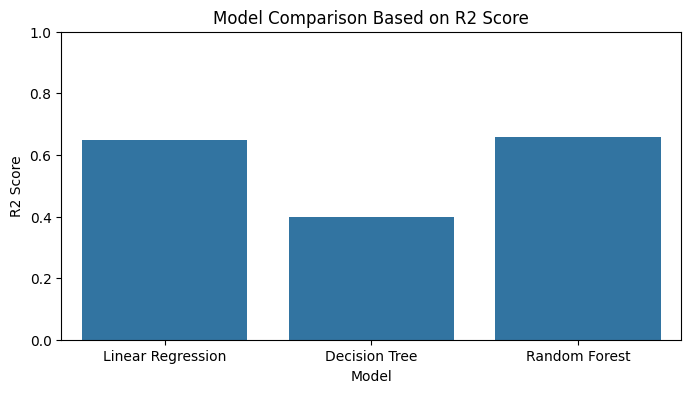

In [30]:
plt.figure(figsize=(8, 4))
sns.barplot(x="Model", y="R2_Score", data=results)
plt.title("Model Comparison Based on R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.ylim(0, 1)
plt.show()

## Step 16: Hyperparameter Tuning using GridSearchCV

Now we tune the Random Forest model.

- Default model settings may not always give the best result.
- GridSearchCV tries different combinations of parameters and selects the best combination.
- Here, we tune Random Forest because it is usually a strong model for regression problems.

In [36]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation R2 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross Validation R2 Score: 0.6464333427996236


## Step 17: Evaluate Tuned Random Forest Model

After tuning, we evaluate the best Random Forest model on the test data.

This shows whether hyperparameter tuning improved model performance.

In [37]:
best_rf = grid_search.best_estimator_

best_rf_pred = best_rf.predict(X_test)

best_rf_r2 = r2_score(y_test, best_rf_pred)
best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_mse = mean_squared_error(y_test, best_rf_pred)
best_rf_rmse = np.sqrt(best_rf_mse)

print("Tuned Random Forest Results")
print("R2 Score:", best_rf_r2)
print("MAE:", best_rf_mae)
print("MSE:", best_rf_mse)
print("RMSE:", best_rf_rmse)

Tuned Random Forest Results
R2 Score: 0.6630285366170898
MAE: 2452.5899851303247
MSE: 15003496.47916926
RMSE: 3873.4347134254454


## Step 18: Residual Plot for Linear Regression

Residuals are the differences between actual and predicted values.

- A residual plot helps us understand model errors.
- If residuals are randomly scattered, the model is performing reasonably.
- If residuals show a pattern, the model may not be capturing the data well.

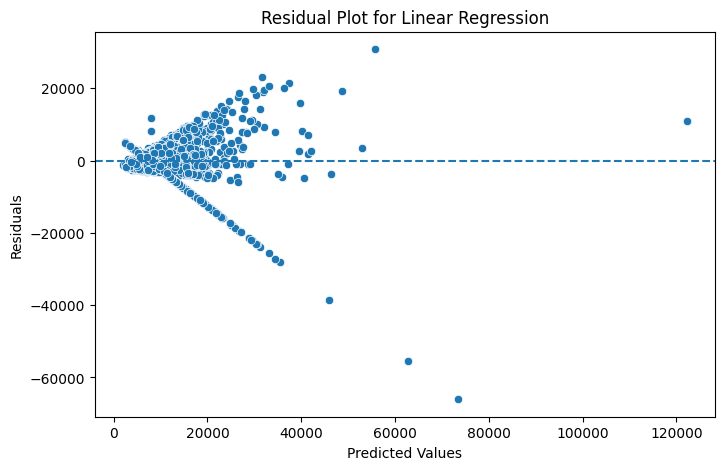

In [38]:
residuals = y_test - lr_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=lr_pred, y=residuals)
plt.axhline(y=0, linestyle="--")
plt.title("Residual Plot for Linear Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

## Step 19: Feature Importance from Random Forest

Random Forest can show which features are most important for prediction.

- Feature importance helps us understand which customer attributes most influence credit card consumption.

This is useful for business insights and model interpretation.

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

In [41]:
best_rf = grid_search.best_estimator_

In [42]:
best_rf = grid_search.best_estimator_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                    Feature  Importance
49         total_card_spend    0.907045
6               dc_cons_jun    0.049293
45  total_credit_card_spend    0.012765
2               dc_cons_apr    0.002442
51        debit_spend_ratio    0.001954
22         debit_amount_apr    0.001777
50       credit_spend_ratio    0.001722
33        credit_amount_jun    0.001550
40         Emp_Tenure_Years    0.001496
3               cc_cons_may    0.001472
46   total_debit_card_spend    0.001456
35          debit_count_jun    0.001427
18             investment_1    0.001155
28        credit_amount_may    0.001134
37               emi_active    0.000960


## Step 20: Visualize Top 15 Important Features

Now we plot the top 15 important features.

A horizontal bar chart makes it easy to identify the strongest predictors of credit card consumption.

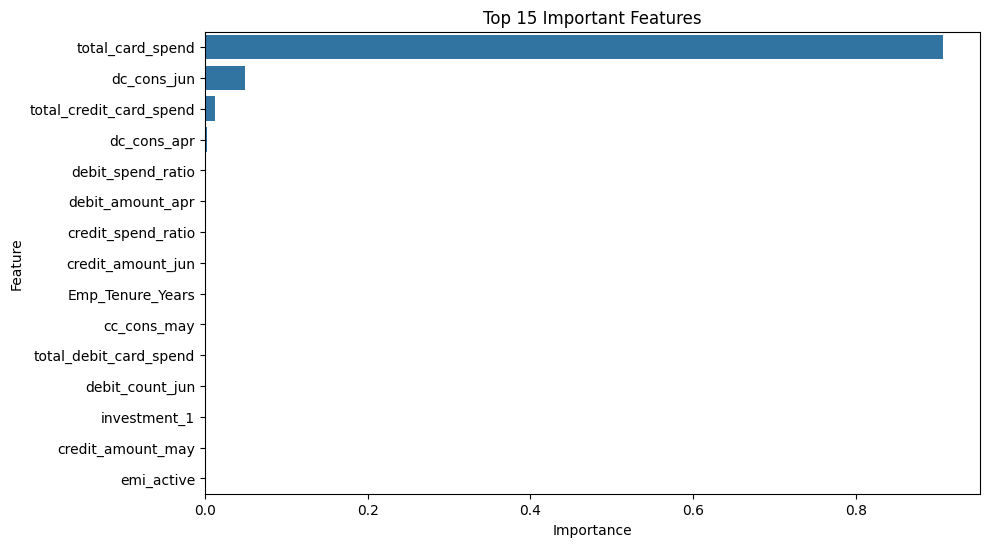

In [44]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Step 21: Save Prediction Results

Now we save actual and predicted credit card consumption values.

The prediction file can be used by a bank to:

- Compare actual and predicted spending
- Identify high-value customers
- Target customers for credit card campaigns
- Support business decision-making

In [45]:
predictions = pd.DataFrame({
    "Actual_cc_cons": y_test,
    "Predicted_cc_cons": best_rf_pred
})

predictions.to_csv("credit_card_consumption_predictions.csv", index=False)

predictions.head()

,Actual_cc_cons,Predicted_cc_cons
10650,3139.3608,5149.160228
2041,7143.5400,5686.905558
8668,9881.1170,7271.328028
1114,15938.5915,20524.087375
13902,2048.7975,4349.234228


# Conclusion

In this notebook, we built and evaluated machine learning models to predict customer credit card consumption.

### Models Implemented

| Model | Purpose |
|---|---|
| Linear Regression | Baseline Model |
| Decision Tree Regressor | Non-linear Prediction |
| Random Forest Regressor | Ensemble Learning |

### Completed Tasks

- Loaded the feature-engineered dataset
- Defined input features and target variable
- Converted categorical columns into numerical format
- Split data into training and testing sets
- Built Linear Regression, Decision Tree, and Random Forest models
- Evaluated models using R² Score, MAE, MSE, and RMSE
- Applied 5-fold cross-validation
- Performed hyperparameter tuning using GridSearchCV
- Created model comparison visualization
- Created residual plot for Linear Regression
- Identified top important features
- Saved prediction results

### Business Insights

1. Customer spending behavior is one of the strongest indicators of future credit card consumption.
2. Recent credit card and debit card activity helps predict future customer spending.
3. Random Forest performed better because it captures complex non-linear relationships.
4. Banks can use the prediction output to identify high-value customers and design targeted marketing campaigns.

### Predicted Output File

The file `credit_card_consumption_predictions.csv` contains:

- Actual credit card consumption values
- Predicted credit card consumption values

This file can help banks compare predicted spending with real spending and make customer-level business decisions.